In [18]:
import numpy as np
from pathlib import Path

import hmp
from hmp import simulations
from hmp.models import FixedEventModel
from hmp.models.base import EventProperties
from hmp.trialdata import TrialData
from matplotlib import pyplot as plt

DATA_DIR = Path("tests", "gen_data")
DATA_DIR_A = DATA_DIR / "dataset_a"
DATA_DIR_B = DATA_DIR / "dataset_b"

In [4]:
# Load data
sfreq = 100
n_events = 3
events = []
event_id = {'stimulus':1}#trigger 1 = stimulus
resp_id = {'response':5}
raws = [DATA_DIR_A / 'dataset_a_raw_raw.fif', DATA_DIR_B / 'dataset_b_raw_raw.fif']
event_files = [DATA_DIR_A / 'dataset_a_raw_raw_generating_events.npy',
                DATA_DIR_B / 'dataset_b_raw_raw_generating_events.npy']
for file in event_files:
    events.append(np.load(file))
event_a = events[0]
event_b = events[1]
# Data reading
epoch_data = hmp.utils.read_mne_data(raws, event_id=event_id, resp_id=resp_id, sfreq=sfreq,
        events_provided=events, verbose=True, reference='average', subj_idx=['a','b'], tmin=-.01)
epoch_data = epoch_data.assign_coords({'condition': ('participant', epoch_data.participant.data)})
positions = simulations.simulation_positions()
hmp_data = hmp.utils.transform_data(epoch_data, n_comp=2,)

Processing participant tests/gen_data/dataset_a/dataset_a_raw_raw.fif's continuous eeg
Opening raw data file tests/gen_data/dataset_a/dataset_a_raw_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60) active
    Range : 0 ... 1199 =      0.000 ...    11.990 secs
Ready.
Reading 0 ... 1199  =      0.000 ...    11.990 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Removing existing average EEG reference projection.
Creating epochs based on following event ID :[1 2 3 4 5]
Adding metadata with 2 columns
2 matching events found
Setting baseline interval to [-0.01, 0.0] s
Applying baseline correction (mode: mean)
Using data from preloaded Raw for 2 events and 502 original time points ...
0 bad epochs dropped
Applying reaction time trim to keep RTs between 0 and 5.01 seconds
2 RTs kept of 2 clean epochs
2 trials were retained for participant tests/gen_data/dataset_a/dataset_a_raw_raw.fi

/Users/joshmac/Documents/repos/hsmm_mvpy/hmp/utils.py:411: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'samples' ('samples',) The recommendation is to set join explicitly for this case.
  epoch_data = xr.concat(
/Users/joshmac/Documents/repos/hsmm_mvpy/hmp/utils.py:703: UserWarning: Data will be modified inplace, re-read the data or use copy=True if multiplecalls to this function
  warn(


In [6]:
# Data b is without noise, recovery should be perfect
data_b = hmp.utils.participant_selection(hmp_data, 'b')
event_properties = EventProperties.create_expected(sfreq=data_b.sfreq)
trial_data_b = TrialData.from_standard_data(data=data_b, template=event_properties.template)
model = FixedEventModel(event_properties, n_events=n_events)
# Recover generating parameters
sim_source_times, true_pars, true_magnitudes, _ = \
    simulations.simulated_times_and_parameters(event_b, model, trial_data_b)
# Fixing true parameter in model
model.parameters = np.array([true_pars])
model.magnitudes = np.array([true_magnitudes])
# Ground truth
true_loglikelihood, true_estimates = model.transform(trial_data_b)
true_topos = hmp.utils.event_topo(epoch_data, true_estimates, mean=True)
true_topos = hmp.utils.event_topo(epoch_data, true_estimates, mean=True)
#Estimate
lkh_b, estimates_b = model.fit_transform(trial_data_b, verbose=True)
test_topos = hmp.utils.event_topo(epoch_data, estimates_b, mean=True)
test_topos = hmp.utils.event_topo(epoch_data, estimates_b, mean=True)

Estimating 3 events model with 1 starting point(s)


In [15]:
max_duration = estimates_b.data.shape[1]
n_stages = n_events + 1
parameters = model.parameters[0].copy()

# Two problem sources:

1) Mass becomes zero everywhere for very small scale parameters
2) Mass becomex infinite at zero for some distributions (an exception is the Weibull) which have
dynamic support depending on the shape parameter. Thus, these distributions (Gamma, inverse Gaussian)
are theoretically only defined with support for duration > 0.

Both problems lead to ``model.distribution_pmf(shape, scale,max_duration)`` returning only zeros and
thus to invalid probability distributions.
In the second case this happens because during the normalization over
``model.pdf(np.arange(max_duration),shape,scale=scale)`` everything becomes ``nan`` due to the
``inf`` mass at index 0.

The first case is indeed likely the result of very short peak-2-peak latencies, resulting in very
small scale parameteter estimates. However, the hack to add 1e-15 is not sufficient to fix this for
two reasons:

- It does not prevent the possibility of total support collapse for stages without a
``location`` parameter.
- It is theoretically invalid for stages with non-zero ``location``: it says that all the mass is
allocated to impossible peak-to-peak distances ``0:locations[stage]``! This is not justified.

The real solution would be to ensure at each EM step that parameter estimates are constrained to
result in valid probability distributions.

## Example of first Problem:

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


/Users/joshmac/Documents/repos/hsmm_mvpy/hmp/models/fixedn.py:829: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p)


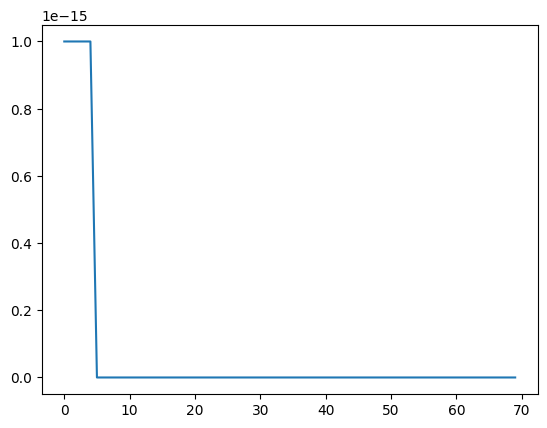

In [ ]:
stage = 1 # Set this to zero to see the total support collapse for stages without location parameter
shape = 2
scale = 1e-7


pmf = np.zeros([max_duration, 1], dtype=np.float64)  # Gamma pmf for each stage scale
locations = np.zeros(n_stages, dtype=int)
locations[1:-1] = model.location

pmf[:, 0] = np.concatenate(
    (
        np.repeat(1e-15, locations[stage]),
        model.distribution_pmf(shape,
                            scale,
                            max_duration)[
            locations[stage] :
        ],
    )
)
print(model.pdf(np.arange(max_duration),shape,scale=scale))
plt.plot(pmf[:,0],label=f"scale: {np.round(scale,decimals=2)}")

## Example of second Problem:

[           inf 6.74811342e-02 2.59113804e-02 1.28897231e-02
 7.12908675e-03 4.17878532e-03 2.54110208e-03 1.58491207e-03
 1.00704202e-03 6.49001195e-04 4.22959640e-04 2.78151037e-04
 1.84291859e-04 1.22872708e-04 8.23615263e-05 5.54616337e-05
 3.74974711e-05 2.54414059e-05 1.73155007e-05 1.18178165e-05
 8.08581235e-06 5.54483289e-06 3.81013696e-06 2.62301709e-06
 1.80884448e-06 1.24933961e-06 8.64143122e-07 5.98507333e-07
 4.15039860e-07 2.88143622e-07 2.00259558e-07 1.39319539e-07
 9.70147450e-08 6.76153583e-08 4.71641538e-08 3.29243345e-08
 2.30007060e-08 1.60792963e-08 1.12480834e-08 7.87337233e-09
 5.51442350e-09 3.86441545e-09 2.70956824e-09 1.90080697e-09
 1.33409695e-09 9.36782372e-10 6.58086673e-10 4.62500541e-10
 3.25175919e-10 2.28714759e-10 1.60928451e-10 1.13273377e-10
 7.97578010e-11 5.61775857e-11 3.95814903e-11 2.78968571e-11
 1.96674316e-11 1.38696236e-11 9.78367512e-12 6.90328144e-12
 4.87215882e-12 3.43950451e-12 2.42870847e-12 1.71536516e-12
 1.21181487e-12 8.562713

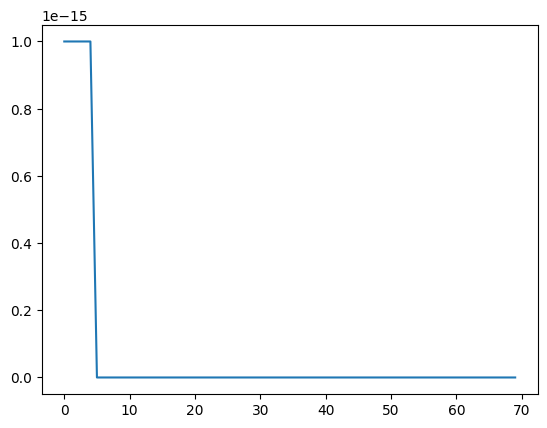

In [66]:
stage = 1
shape = 0.1
scale = 3


pmf = np.zeros([max_duration, 1], dtype=np.float64)  # Gamma pmf for each stage scale
locations = np.zeros(n_stages, dtype=int)
locations[1:-1] = model.location

pmf[:, 0] = np.concatenate(
    (
        np.repeat(1e-15, locations[stage]),
        model.distribution_pmf(shape,
                            scale,
                            max_duration)[
            locations[stage] :
        ],
    )
)
print(model.pdf(np.arange(max_duration),shape,scale=scale))
plt.plot(pmf[:,0],label=f"scale: {np.round(scale,decimals=2)}")